<a href="https://colab.research.google.com/github/PDM-15/AML-2026/blob/master/01.09.2026/Assignment5(income).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Intercept: [0.14170387]
Slope: [0.7247687]
Predicted happpiness score: [6.30223784]


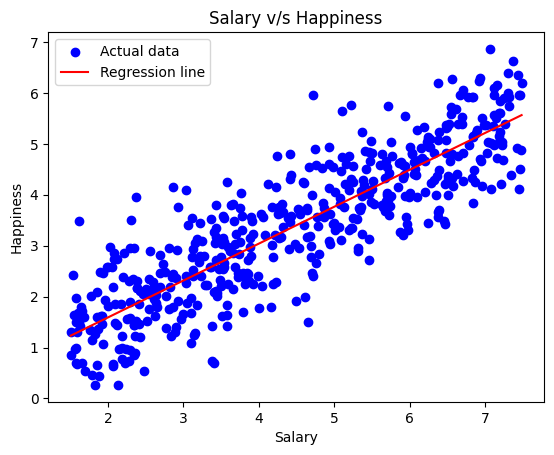

Mean Absolute Error: 0.6269683431894553
Mean Squared Error: 0.590146394343082
Root Mean Squared Error: 0.768209863476825
R-squared: 0.6662585264303965


In [6]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

drive.mount('/content/drive')

data = pd.read_csv("drive/My Drive/Dataset/income_data.csv")
dataset = data

X = dataset[['income']]
y = dataset[['happiness']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

new_data = pd.DataFrame([[8.5]], columns=['income'])
predicted_happiness = model.predict(new_data)
print("Predicted happpiness score:", predicted_happiness[0])

y_pred = model.predict(X_test)

plt.scatter(X, y, color = "blue", label="Actual data")
plt.xlabel("Salary")
plt.ylabel("Happiness")
plt.title("Salary v/s Happiness")

X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(X_line, model.predict(pd.DataFrame(X_line, columns=['income'])), color="red", label="Regression line")

plt.legend()
plt.show()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)
